# Statistical Classification and Logistic Regression
### Use Case: Network Intrusion Detection
> **Dataset context:** Inspired by the NSL-KDD network traffic dataset. Each record represents a single network connection. The goal is to classify it as **Normal (0)** or **Attack (1)** based on connection features.

---
## 1. Why Linear Regression Won't Work to predict an attack with the given Data

We want to predict **whether it is an attack or not** — a binary outcome.

Our single feature: **number of failed login attempts** on the connection.  
Our label: `0 = Normal`, `1 = Attack`

The intuition is simple: the more failed logins, the more likely the connection is a brute-force attack.

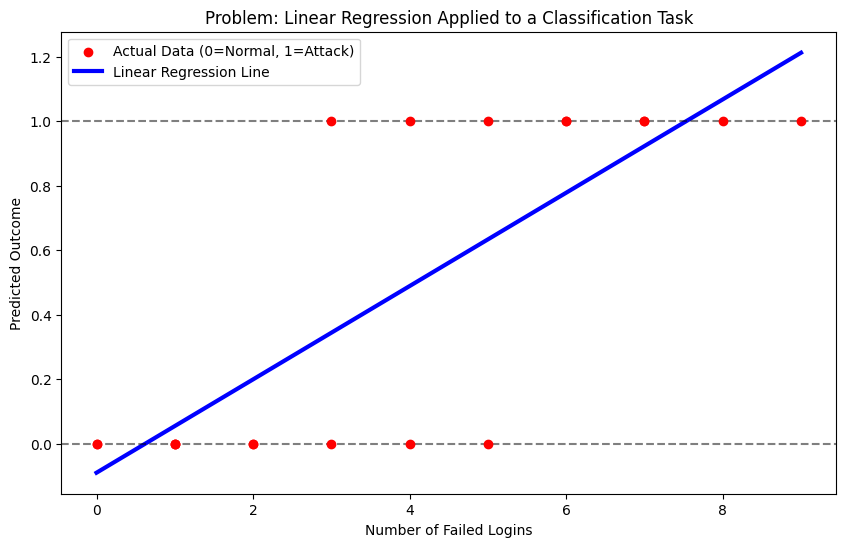

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Feature: number of failed logins  |  Label: 0 = Normal, 1 = Attack
failed_logins = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4,
                           4, 5, 5, 6, 6, 7, 7, 8, 9]).reshape(-1, 1)
is_attack     = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
                           1, 0, 1, 1, 1, 1, 1, 1, 1])

# Attempt to use linear regression for classification
linear_model = LinearRegression()
linear_model.fit(failed_logins, is_attack)
line = linear_model.predict(failed_logins)

plt.figure(figsize=(10, 6))
plt.scatter(failed_logins, is_attack, color='red', zorder=20, label='Actual Data (0=Normal, 1=Attack)')
plt.plot(failed_logins, line, color='blue', linewidth=3, label='Linear Regression Line')
plt.xlabel('Number of Failed Logins')
plt.ylabel('Predicted Outcome')
plt.title('Problem: Linear Regression Applied to a Classification Task')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

⚠️  Problem: The linear model can predict values below 0 or above 1.

A probability of -0.2 or 1.3 makes no sense for classification.

## Introduction to Logistic Regression

**Logistic Regression** solves this by squashing any real-valued number into a probability between 0 and 1 using the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = w_0 + w_1 x$ (the same linear combination as before, but now passed through the sigmoid).

In our context:  
- The output $\sigma(z)$ represents **P(Attack)** — the probability that the connection is malicious.
- If $\sigma(z) \geq 0.5$ → classify as **Attack (1)**  
- If $\sigma(z) < 0.5$ → classify as **Normal (0)**

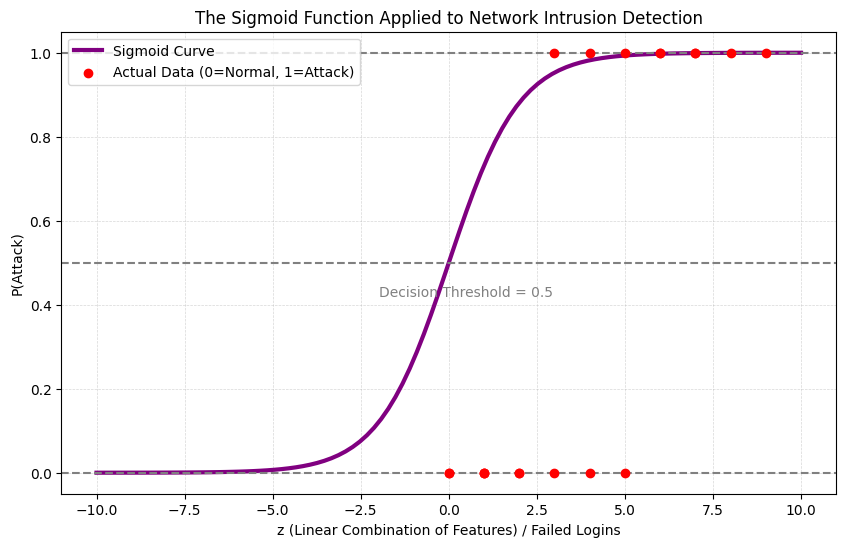

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
p = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, p, color='purple', linewidth=3, label='Sigmoid Curve')
plt.scatter(failed_logins, is_attack, color='red', zorder=20, label='Actual Data (0=Normal, 1=Attack)')
plt.xlabel('z (Linear Combination of Features) / Failed Logins')
plt.ylabel('P(Attack)')
plt.title('The Sigmoid Function Applied to Network Intrusion Detection')
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.axhline(y=0, color='grey', linestyle='--')
plt.axhline(y=1, color='grey', linestyle='--')
plt.text(0.5, 0.42, 'Decision Threshold = 0.5', ha='center', color='grey')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

---
## 2. An Introduction to Statistical Classification

**Classification** is the process of assigning an input to a predefined category.

In network security, we're asking: *"Given what we observe about a connection, which bucket does it belong to — Normal or Attack?"*

### Key Terminology in Our Context
- **Classifier**: Our Logistic Regression model.
- **Features**: Connection attributes — failed logins, duration, bytes transferred, protocol type, etc.
- **Classes**: `Normal (0)` and `Attack (1)`.
- **Decision Boundary**: The line (or surface) the model learns that separates normal traffic from attack traffic.

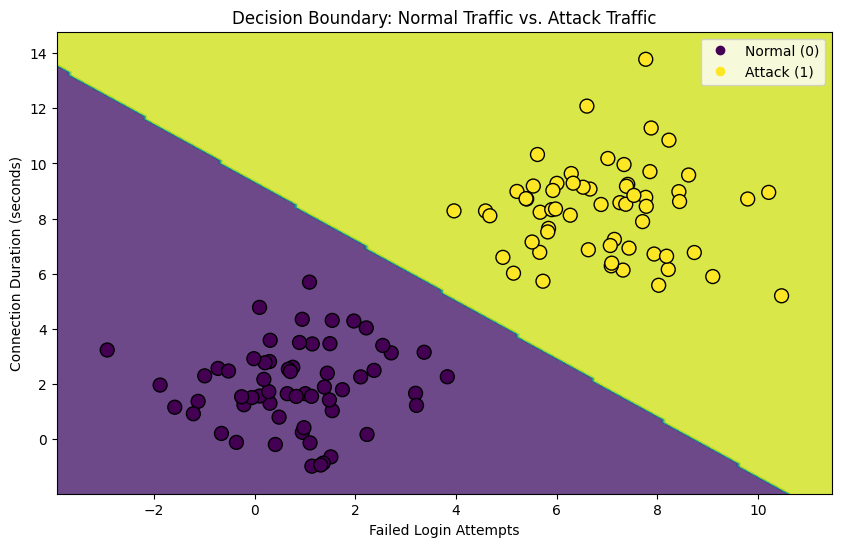

In [57]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Simulate 2-feature network traffic data:
# Cluster 0 = Normal traffic (low failed logins, short duration)
# Cluster 1 = Attack traffic (high failed logins, long duration)
X, y = make_blobs(n_samples=120,
                  centers=[(1, 2), (7, 8)],
                  n_features=2,
                  random_state=42,
                  cluster_std=1.5)

# Train a logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Generate decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Change the plot style to default (white background)
plt.style.use('default')

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=100, cmap='viridis')
plt.xlabel('Failed Login Attempts')
plt.ylabel('Connection Duration (seconds)')
plt.title('Decision Boundary: Normal Traffic vs. Attack Traffic')
plt.legend(handles=scatter.legend_elements()[0], labels=['Normal (0)', 'Attack (1)'])
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.show()

---
## 3. Statistical Classification Using Logistic Regression

Now we build the actual classifier using `scikit-learn`. We use **failed logins** as our single feature to stay parallel with the conceptual example above.

The model learns the optimal sigmoid curve over our training data, then applies the 0.5 threshold to label each connection.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Our dataset (failed logins → attack label)
failed_logins = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4,
                           4, 5, 5, 6, 6, 7, 7, 8, 9]).reshape(-1, 1)
is_attack     = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
                           1, 0, 1, 1, 1, 1, 1, 1, 1])

# Step 2: Train the Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(failed_logins, is_attack)

# Step 3: Predict probabilities
probabilities = log_reg.predict_proba(failed_logins)
predictions   = log_reg.predict(failed_logins)

# Step 4: Evaluate accuracy
accuracy = accuracy_score(is_attack, predictions)
print("Failed Logins | P(Normal) | P(Attack) | Predicted | Actual")
print("-" * 65)
for i in range(len(failed_logins)):
    fl = failed_logins[i][0]
    pn = probabilities[i][0]
    pa = probabilities[i][1]
    pr = predictions[i]
    ac = is_attack[i]
    flag = "✅" if pr == ac else "❌"
    print(f"      {fl:2d}      |   {pn:.3f}   |   {pa:.3f}   |     {pr}     |   {ac}  {flag}")

print(f"\nModel Accuracy: {accuracy * 100:.1f}%")

Failed Logins | P(Normal) | P(Attack) | Predicted | Actual
-----------------------------------------------------------------
       0      |   0.982   |   0.018   |     0     |   0  ✅
       0      |   0.982   |   0.018   |     0     |   0  ✅
       1      |   0.954   |   0.046   |     0     |   0  ✅
       1      |   0.954   |   0.046   |     0     |   0  ✅
       1      |   0.954   |   0.046   |     0     |   0  ✅
       2      |   0.884   |   0.116   |     0     |   0  ✅
       2      |   0.884   |   0.116   |     0     |   0  ✅
       3      |   0.737   |   0.263   |     0     |   0  ✅
       3      |   0.737   |   0.263   |     0     |   1  ❌
       4      |   0.507   |   0.493   |     0     |   0  ✅
       4      |   0.507   |   0.493   |     0     |   1  ❌
       5      |   0.275   |   0.725   |     1     |   0  ❌
       5      |   0.275   |   0.725   |     1     |   1  ✅
       6      |   0.123   |   0.877   |     1     |   1  ✅
       6      |   0.123   |   0.877   |     1    

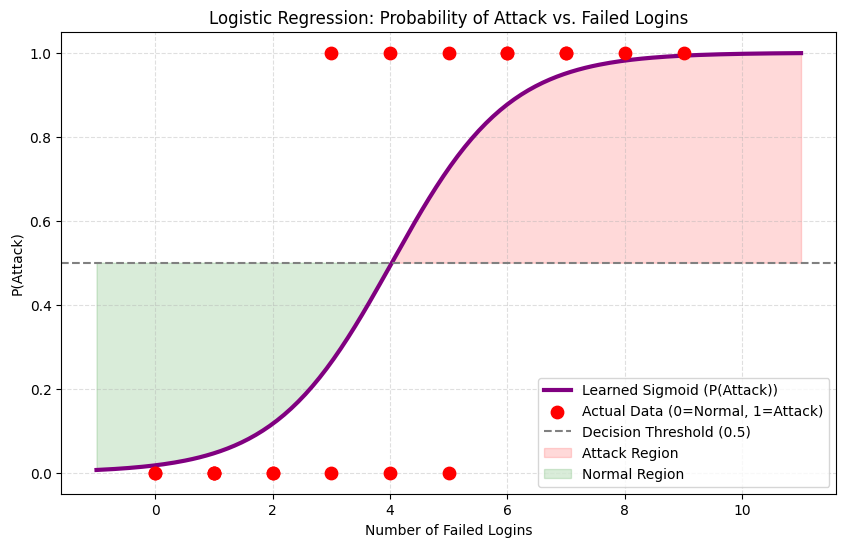

In [59]:
# Visualise the learned sigmoid curve over our data
x_range = np.linspace(-1, 11, 200).reshape(-1, 1)
p_range = log_reg.predict_proba(x_range)[:, 1]

# Change the plot style to default (white background)
plt.style.use('default')
plt.figure(figsize=(10, 6))
plt.plot(x_range, p_range, color='purple', linewidth=3, label='Learned Sigmoid (P(Attack))')
plt.scatter(failed_logins, is_attack, color='red', zorder=20, s=80, label='Actual Data (0=Normal, 1=Attack)')
plt.axhline(y=0.5, color='grey', linestyle='--', label='Decision Threshold (0.5)')
plt.fill_between(x_range.flatten(), 0.5, p_range, where=(p_range >= 0.5),
                 alpha=0.15, color='red', label='Attack Region')
plt.fill_between(x_range.flatten(), p_range, 0.5, where=(p_range < 0.5),
                 alpha=0.15, color='green', label='Normal Region')
plt.xlabel('Number of Failed Logins')
plt.ylabel('P(Attack)')
plt.title('Logistic Regression: Probability of Attack vs. Failed Logins')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

---
## 4. Log-Loss Function (Cross-Entropy Loss)

### Why Log-Loss Matters for Intrusion Detection

**Log-loss** measures how *well-calibrated* our model's probabilities are — not just whether the final classification was right or wrong, but **how confident it was** when it was right or wrong.

In cybersecurity, this is critical:
> A model that says **P(Attack) = 0.51** and gets it right is less valuable than one that says **P(Attack) = 0.97** and gets it right — the second model gives an analyst actionable confidence.

Conversely, a model that says **P(Attack) = 0.02** when the connection *was* an attack is catastrophically penalised by log-loss, as it should be.

#### The Formula

$$\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]$$

where:
- $y_i = 1$ if the connection was an **Attack**, $0$ if **Normal**
- $p_i$ is the model's predicted probability that connection $i$ is an attack

In [60]:
def log_loss(y_true, y_prob):
    """
    Compute the log-loss (cross-entropy loss) for binary classification.

    In the intrusion detection context:
    - y_true: 1 if the connection was an attack, 0 if normal.
    - y_prob: Model's predicted probability that the connection is an attack.

    A high log-loss means the model was confidently wrong — the worst outcome
    in a security setting.

    Parameters:
        y_true (np.ndarray): True binary labels (0=Normal, 1=Attack).
        y_prob (np.ndarray): Predicted probabilities for class 1 (Attack).

    Returns:
        float: Log-loss value.
    """
    # Clip to avoid log(0) which is undefined
    eps    = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    loss   = -np.mean(
        y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)
    )
    return loss

# Calculate log-loss using our model's predicted probabilities
logloss_value = log_loss(is_attack, probabilities[:, 1])

print(f"Log-loss (Cross-Entropy Loss): {logloss_value:.4f}")

Log-loss (Cross-Entropy Loss): 0.2869


### Interpretation:
A log-loss of 0.2869 means the model is generally confident
and correct in its probability estimates.

The closer to 0, the better the model is at distinguishing attacks from normal traffic.

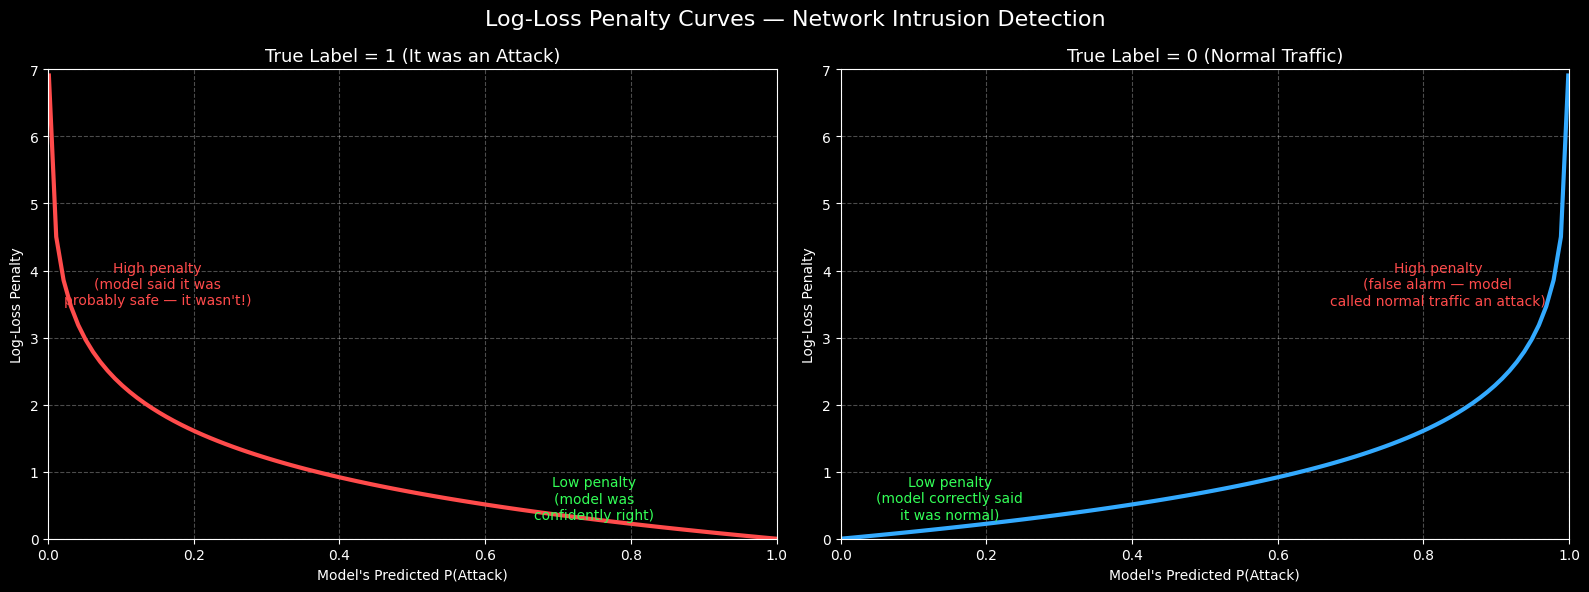

In [61]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 100)

loss_for_y1 = -np.log(p)      # True label = Attack (1)
loss_for_y0 = -np.log(1 - p)  # True label = Normal (0)

# Change the plot style to dark background
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Log-Loss Penalty Curves — Network Intrusion Detection', fontsize=16, color='white')

# Scenario A: It WAS an attack (y=1)
ax1.plot(p, loss_for_y1, color='#FF4B4B', lw=3)
ax1.set_title('True Label = 1 (It was an Attack)', color='white', fontsize=13)
ax1.set_xlabel('Model\'s Predicted P(Attack)', color='white')
ax1.set_ylabel('Log-Loss Penalty', color='white')
ax1.tick_params(colors='white')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.text(0.75, 0.3, 'Low penalty\n(model was\nconfidently right)', color='#33FF57', ha='center', fontsize=10)
ax1.text(0.15, 3.5, 'High penalty\n(model said it was\nprobably safe — it wasn\'t!)', color='#FF4B4B', ha='center', fontsize=10)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 7)

# Scenario B: It was NOT an attack (y=0)
ax2.plot(p, loss_for_y0, color='#33AAFF', lw=3)
ax2.set_title('True Label = 0 (Normal Traffic)', color='white', fontsize=13)
ax2.set_xlabel('Model\'s Predicted P(Attack)', color='white')
ax2.set_ylabel('Log-Loss Penalty', color='white')
ax2.tick_params(colors='white')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.text(0.15, 0.3, 'Low penalty\n(model correctly said\nit was normal)', color='#33FF57', ha='center', fontsize=10)
ax2.text(0.82, 3.5, 'High penalty\n(false alarm — model\ncalled normal traffic an attack)', color='#FF4B4B', ha='center', fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 7)

plt.tight_layout()
plt.show()

### Summary of the Full Workflow

1. **Theory**: Logistic Regression uses the Sigmoid function to output a probability between 0 and 1 — in our case, P(Attack).
2. **Task Definition**: We framed network connection analysis as a binary classification problem (Normal vs. Attack).
3. **Implementation**: We trained a `LogisticRegression` model on failed login counts to learn the optimal decision boundary.
4. **Prediction**: The model outputs P(Attack) for any new connection. If P(Attack) ≥ 0.5, we flag it as an attack.
5. **Evaluation**: Log-loss penalises not just incorrect classifications, but *confidently wrong* predictions — a crucial property in security systems.

---
## My Three Talking Points


---

### Talking Point 1 — Why the Sigmoid Is the Right Tool for Security Classification

> The sigmoid function is not just a mathematical convenience. For network intrusion detection, the output $P(\text{Attack}) \in [0, 1]$ is directly meaningful — it represents the model's *confidence* that a connection is malicious. A linear model cannot give us this because it can produce values like $-0.3$ or $1.5$, which are impossible as probabilities. The sigmoid forces the model to speak in the language of probability, which is exactly what a security analyst needs to prioritise their response.

**Key code reference:** `def sigmoid(z): return 1 / (1 + np.exp(-z))` and the `predict_proba()` call on the trained model.

---

### Talking Point 2 — The Decision Threshold Is Not Always 0.5

> In the original pass/fail example, a 0.5 threshold is symmetric and fair — missing a pass is no worse than missing a fail. In intrusion detection, this assumption breaks completely. A **false negative** (missing a real attack) is far more costly than a **false positive** (flagging normal traffic as suspicious). In practice, we would lower the threshold — perhaps to 0.3 or 0.2 — to catch more attacks at the cost of more false alarms. The logistic regression model's output of a *continuous probability* is what makes this threshold tuning possible at all.

**Key code reference:** The decision boundary visualisation and the `predict_proba()` vs. `predict()` distinction.

---

### Talking Point 3 — Log-Loss Captures the Cost of a Confident Wrong Answer

> Accuracy alone is a poor metric for intrusion detection — a model that labels everything as Normal on a dataset with 5% attacks would still achieve 95% accuracy while being completely useless. Log-loss solves this by penalising *confident wrong predictions exponentially*. The penalty curve for $y=1$ (it was an attack) shows that if the model predicted $P(\text{Attack}) = 0.05$ when the connection was actually an attack, the loss spikes dramatically. This is exactly the right behaviour: we want our loss function to be most sensitive to the scenario where the model told us we were safe and we weren't.

**Key code reference:** The custom `log_loss()` function and the two penalty curve plots.

---